In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os
import scipy
import sys

sys.path.append('../../Share')
import shared_iENG_sENG
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D


def X_y_from_matfile(path, modality, session):
    X, y = [], []

    if modality=='EMG':
        bluetooth_id = 'E8DD80E550BB'
    elif modality=='ENG':
        bluetooth_id = 'E9AD0E7DCC2B'

    data_per_class_files = os.listdir(path+f'{modality}_{session}/{bluetooth_id}/raw/')

    for cls in data_per_class_files:
        input_path = path+f'{modality}_{session}/{bluetooth_id}/raw/{cls}/'
        files = os.listdir(input_path)

        mat = scipy.io.loadmat(input_path+files[0])
        x_tmp = mat['Data_Fea'].transpose(2, 0, 1)

        X.append(x_tmp.reshape(x_tmp.shape[0], x_tmp.shape[1]*x_tmp.shape[2]))
        y.append(mat['Data_Cls'].ravel())

    return X, y


from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist

def t_sne_compute_dist(sEMG, sENG, iENG, vis=False):

    # Stack all for t-SNE
    X_all = np.vstack([sEMG, sENG, iENG])
    labels = np.array([0]*sEMG.shape[0] + [1]*sENG.shape[0] + [2]*iENG.shape[0])

    # t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(X_all)

    names = ['sEMG', 'sENG', 'iENG']
    # Visualize
    if vis:
        plt.figure(figsize=(8,6))
        colors = ['r', 'g', 'b']

        for i, c, name in zip(range(3), colors, names):
            plt.scatter(X_tsne[labels==i, 0], X_tsne[labels==i, 1], c=c, label=name, alpha=0.6, s=20)

        plt.legend()
        plt.title("t-SNE of three datasets")
        plt.show()

    # Compute prototypes (mean feature vector)
    proto_i = sEMG.mean(axis=0)
    proto_s1 = sENG.mean(axis=0)
    proto_s2 = iENG.mean(axis=0)

    # Stack prototypes
    prototypes = np.vstack([proto_i, proto_s1, proto_s2])

    # Compute pairwise distances
    dist_matrix = cdist(prototypes, prototypes, metric='euclidean')
    dist_matrix = pd.DataFrame(dist_matrix, index=names, columns=names)
    #print("Pairwise distances between prototypes:\n", dist_matrix)
    return dist_matrix


from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def t_sne_compute_dist_3d(sEMG, sENG, iENG):

    # Stack all for t-SNE
    X_all = np.vstack([sEMG, sENG, iENG])
    labels = np.array([0]*sEMG.shape[0] + [1]*sENG.shape[0] + [2]*iENG.shape[0])

    # 3D t-SNE
    tsne = TSNE(n_components=3, random_state=42)
    X_tsne = tsne.fit_transform(X_all)

    # 3D Visualization
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')

    colors = ['r', 'g', 'b']
    names = ['sEMG', 'sENG', 'iENG']

    for i, c, name in zip(range(3), colors, names):
        ax.scatter(
            X_tsne[labels==i, 0],
            X_tsne[labels==i, 1],
            X_tsne[labels==i, 2],
            c=c, label=name, alpha=0.6, s=20
        )

    ax.set_title("3D t-SNE of three datasets")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.set_zlabel("t-SNE 3")
    ax.legend()
    plt.show()

    # Compute prototypes (mean feature vector)
    proto_i = sEMG.mean(axis=0)
    proto_s1 = sENG.mean(axis=0)
    proto_s2 = iENG.mean(axis=0)

    # Stack prototypes
    prototypes = np.vstack([proto_i, proto_s1, proto_s2])

    # Compute pairwise distances
    dist_matrix = cdist(prototypes, prototypes, metric='euclidean')
    dist_matrix = pd.DataFrame(dist_matrix, index=names, columns=names)

    return dist_matrix

# iENG - invasive

- feature set : 이미 있음
- zc, ssc, wl, wilson amplitude, mav, msq, RMS, V3, log detector, Difference absolute standard deviation, Maximum fractal length, Myopulse percentage rate, Mean absolute value slope, Weighted mean absolute
- commons: MAV, wamp, SSC, ZC, WL, RMS = idx: [0,1,2,3,4,6]

In [2]:
def get_iENG(gesture_label, feature_set):
    path = 'C:/Users/hml76/Desktop/Jupyter/Federated Prototype Learning/Dataset/Ours_cleaned/'
    fname = os.listdir(path)
    iENG_subjects = {"subject2": {"X": [], "Y": []}, "subject3": {"X": [], "Y": []}}

    for f in fname:
        for i in range(10):
            X = np.array(pd.read_csv(path + f'{f}/rep{i}_X.csv'))
            y = np.array(pd.read_csv(path + f'{f}/rep{i}_Y.csv'))
            #indices = np.random.permutation(len(X)) # shuffle
            #X, y = X[indices], y[indices]

            y_int = np.argmax(y, axis=1)
            num_classes = np.max(y_int) + 1

            if "subject2" in f:
                iENG_subjects["subject2"]["X"].append(X)
                iENG_subjects["subject2"]["Y"].append(y_int)
            elif "subject3" in f:
                iENG_subjects["subject3"]["X"].append(X)
                iENG_subjects["subject3"]["Y"].append(y_int)

    final_session = 4
    y = iENG_subjects["subject2"]['Y'][2:final_session] + iENG_subjects["subject3"]['Y'][2:final_session]
    x = iENG_subjects["subject2"]['X'][2:final_session] + iENG_subjects["subject3"]['X'][2:final_session]

    y = np.concatenate(y, axis=0)
    x = np.concatenate(x, axis=0)
    x = x.reshape(x.shape[0], 16, 14)

    x = x[:, [0, 4, 8, 12], :][:, :, feature_set]   # (N, 4, 5)
    x = x.reshape(x.shape[0], -1)           # (N, 20)
    # others => [0, 2, 3, 4, 12] # ZC, WL, WAMP, MAV, MAVS

    #mask = (y == 0)
    #mask = (y >= 1) & (y <= 5)
    mask = (y == gesture_label)
    iENG_x_zero = x[mask]
    iENG_y_zero = y[mask]
    print(iENG_x_zero.shape, iENG_y_zero.shape)

    return iENG_x_zero, iENG_y_zero

# sEMG
- commons: MAV, wamp, SSC, ZC, WL, RMS
- 11TD features = idx: [0,1,2,3] = MAV, WL, WAMP, ZC
- 9 TD features = idx: [1,2] = SSC, RMS
- gesture_label1, gesture_label2로 나눈 이유: Ninapro 에서는 접고 / 펴는게 각각 gesture로 되어있어서 일부러 2개로 함

In [3]:
import re
from sklearn.preprocessing import OneHotEncoder

def Error_in_Y(Y_dataset):
    new_Y = []
    for i in range(len(Y_dataset)):
        decoded_string = str(Y_dataset[i])
        match = re.search(r'\(\d+, (\d+)\)', decoded_string)

        if match:
            extracted_value = int(match.group(1))
            new_Y.append(extracted_value)

        else: print("Error")

    labels = np.array(new_Y).reshape(-1, 1)

    encoder = OneHotEncoder(categories=[range(np.max(new_Y)+1)])
    one_hot_encoded = encoder.fit_transform(labels).toarray()

    return one_hot_encoded

def get_sEMG(b_path, sub_lst, g_label1, g_label2, f_idx, num_ch, num_feat, db):
    X_lst, y_lst = [], []

    for sub in sub_lst:
        for rep in range(1, 6):
            try:
                X = pd.read_csv(b_path + f'/Sub{sub}/Sub{sub}_Rep{rep}_data.csv')
                y = pd.read_csv(b_path + f'/Sub{sub}/Sub{sub}_Rep{rep}_label.csv')
            except:
                X = pd.read_csv(b_path + f'/Sub{sub}_serial/Sub{sub}_Rep{rep}_data.csv')
                y = pd.read_csv(b_path + f'/Sub{sub}_serial/Sub{sub}_Rep{rep}_label.csv')

            if db == "DB1_TD2" or db == "DB5_TD2":
                y = Error_in_Y(np.array(y))

            y = np.argmax(y, axis=1)
            mask = (y >= g_label1) & (y <= g_label2)
            X = np.array(X).reshape(X.shape[0], num_ch, num_feat)
            #print(X.shape)

            feature_idx = np.atleast_1d(f_idx)
            X = X[:, [2,6,8,0], :][:, :, feature_idx]
            #print("After selection:", X.shape)  # (11944, 4, 5)

            # optional flatten
            X = X.reshape(X.shape[0], -1)
            #print("After flatten:", X.shape)  # (11944, 20)

            X_lst.append(X[mask])
            y_lst.append(y[mask])

    sEMG_x = np.concatenate(X_lst, axis=0)
    sEMG_y = np.concatenate(y_lst, axis=0)

    print(sEMG_x.shape, sEMG_y.shape)
    return sEMG_x, sEMG_y

# sENG
- feature ready
- 14 features
- commons: MAV, wamp, SSC, ZC, WL, RMS = idx: [0,1,2,3,4,6]

In [4]:
def get_sENG(gesture_label, feature_set):
    bluetooth_id = 'E9AD0E7DCC2B'
    base_path = 'C:/Users/hml76/PycharmProjects/MindForce/data/sENG_iENG/'
    X_sENG_sub1, y_sENG_sub1 = shared_iENG_sENG.return_X_y_get_from_matfile(path = base_path+f'Hunmin/{bluetooth_id}/raw/', num_session=[0,1,2,3,4], balance=True)
    X_sENG_sub2, y_sENG_sub2 = shared_iENG_sENG.return_X_y_get_from_matfile(path = base_path+f'Byeongchan/{bluetooth_id}/raw/', num_session=[0,1,2,3,4], balance=True)
    X_sENG_sub3, y_sENG_sub3 = shared_iENG_sENG.return_X_y_get_from_matfile(path = base_path+f'Minjeong/{bluetooth_id}/raw/', num_session=[0,1,2,3,4], balance=True)
    X_sENG, y_sENG = np.concatenate([X_sENG_sub1, X_sENG_sub2, X_sENG_sub3], axis=0), np.concatenate([y_sENG_sub1, y_sENG_sub2, y_sENG_sub3], axis=0)

    x, y = X_sENG, y_sENG

    #mask = (y == 0)
    #mask = (y >= 1) & (y <= 5)
    mask = (y == gesture_label)
    sENG_x_zero = x[mask]
    sENG_y_zero = y[mask]

    sENG_x_zero = sENG_x_zero[:, :, feature_set]
    sENG_x_zero = sENG_x_zero.reshape(sENG_x_zero.shape[0], 4*len(feature_set))

    print(sENG_x_zero.shape, sENG_y_zero.shape)
    return sENG_x_zero, sENG_y_zero

- Target class: 한손가락씩 접었다가 펴는거 or resting state
- Exercise A만 가능 : DB1, DB4, DB5

In [5]:
TD1_path_DB1 = 'C:/Users/hml76/Desktop/Jupyter/Federated Prototype Learning/Dataset/DB1'
TD1_path_DB4 = 'C:/Users/hml76/Desktop/Jupyter/Federated Prototype Learning/Dataset/DB4'
TD1_path_DB5 = 'C:/Users/hml76/Desktop/Jupyter/Federated Prototype Learning/Dataset/DB5'
TD2_path_DB1 = 'C:/Users/hml76/Desktop/Jupyter/Generalization - EMG/new_features_data/DB1_TD2'
TD2_path_DB4 = 'C:/Users/hml76/Desktop/Jupyter/Generalization - EMG/new_features_data/DB4_TD2'
TD2_path_DB5 = 'C:/Users/hml76/Desktop/Jupyter/Generalization - EMG/new_features_data/DB5_TD2'
# Index finger : class 1-2 / Middle finger : class 3-4 / Ring finger : class 5-6 / Pinky finger : class 7-8 / Thumb : class 9-10  or  11-12

f_idx_TD1 = [0,1,2,3] #MAV, WL, WAMP, ZC
f_idx_TD2 = [1,2]  #SSC, RMS
DB1_channels, DB4_channels, DB5_channels = 10, 12, 16
TD1_features, TD2_features, TD2_features_DB4 = 11, 8, 10

- commons: MAV, wamp, SSC, ZC, WL, RMS, MAVS = idx: [0,1,2,3,4,6,12] => iENG, sENG
##### zc, ssc, wl, wilson amplitude, mav, msq, RMS, V3, log detector, Difference absolute standard deviation, Maximum fractal length, Myopulse percentage rate, Mean absolute value slope, Weighted mean absolute
#### sEMG
- 11TD features = idx: [0,1,2,3] = MAV, WL, WAMP, ZC
- 9 TD features = idx: [1,2] = SSC, RMS

In [8]:
def Get_TSNE_dist(ENG_feature_idx, EMG_feature_idx, DB1_path, DB4_path, DB5_path, num_f, DBs):
    from sklearn.preprocessing import StandardScaler

    dist = []

    for ENG_G in [2,3,4,5,1]: #gesture
        print("===========================  Gesture",ENG_G,"===========================")
        if ENG_G == 2: EMG_G = [1,2]
        if ENG_G == 3: EMG_G = [3,4]
        if ENG_G == 4: EMG_G = [5,6]
        if ENG_G == 5: EMG_G = [7,8]
        if ENG_G == 1: EMG_G = [9,10]

        sENG_X, sENG_y = get_sENG(gesture_label=ENG_G, feature_set=ENG_feature_idx)
        iENG_X, iENG_y = get_iENG(gesture_label=ENG_G, feature_set=ENG_feature_idx)
        #print("DB1")
        sEMG_X_DB1, sEMG_y_DB1 = get_sEMG(b_path=DB1_path, sub_lst=[1,2,3,4,5], g_label1=EMG_G[0], g_label2=EMG_G[1], f_idx=EMG_feature_idx, num_ch=DB1_channels, num_feat=num_f, db=DBs[0])
        #print("DB4")
        sEMG_X_DB4, sEMG_y_DB4 = get_sEMG(b_path=DB4_path, sub_lst=[1,2,3,4,5], g_label1=EMG_G[0], g_label2=EMG_G[1], f_idx=EMG_feature_idx, num_ch=DB4_channels, num_feat=10, db=DBs[1])
        #print("DB5")
        sEMG_X_DB5, sEMG_y_DB5 = get_sEMG(b_path=DB5_path, sub_lst=[1,2,3,4,5], g_label1=EMG_G[0], g_label2=EMG_G[1], f_idx=EMG_feature_idx, num_ch=DB5_channels, num_feat=num_f, db=DBs[2])

        #feature 를 따로 비교하는거라 scaling이 필요없음
        #sEMG_X_DB5 = StandardScaler().fit_transform(sEMG_X_DB5)
        #sEMG_X_DB4 = StandardScaler().fit_transform(sEMG_X_DB4)
        #sEMG_X_DB1 = StandardScaler().fit_transform(sEMG_X_DB1)
        #sENG_X = StandardScaler().fit_transform(sENG_X)
        #iENG_X = StandardScaler().fit_transform(iENG_X)

        dist_DB1 = t_sne_compute_dist(sEMG_X_DB1, sENG_X, iENG_X, vis=False)
        dist_DB4 = t_sne_compute_dist(sEMG_X_DB4, sENG_X, iENG_X, vis=False)
        dist_DB5 = t_sne_compute_dist(sEMG_X_DB5, sENG_X, iENG_X, vis=False)

        dist.append([dist_DB1, dist_DB4, dist_DB5])

    return dist

In [39]:
# MAV
MAV_dist = Get_TSNE_dist(ENG_feature_idx=[0], EMG_feature_idx=[0], DB1_path=TD1_path_DB1, DB4_path=TD1_path_DB4, DB5_path=TD1_path_DB5)

===========================  Gesture 2 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(5398, 4) (5398,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Gesture 3 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(4953, 4) (4953,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Gesture 4 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(4727, 4) (4727,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Gesture 5 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(4619, 4) (4619,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Ges

In [40]:
# WAMP
WAMP_dist = Get_TSNE_dist(ENG_feature_idx=[1], EMG_feature_idx=[2], DB1_path=TD1_path_DB1, DB4_path=TD1_path_DB4, DB5_path=TD1_path_DB5)

===========================  Gesture 2 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(5398, 4) (5398,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Gesture 3 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(4953, 4) (4953,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Gesture 4 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(4727, 4) (4727,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Gesture 5 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(4619, 4) (4619,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Ges

In [41]:
# Wavelength
WL_dist = Get_TSNE_dist(ENG_feature_idx=[4], EMG_feature_idx=[1], DB1_path=TD1_path_DB1, DB4_path=TD1_path_DB4, DB5_path=TD1_path_DB5)

===========================  Gesture 2 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(5398, 4) (5398,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Gesture 3 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(4953, 4) (4953,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Gesture 4 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(4727, 4) (4727,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Gesture 5 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(4619, 4) (4619,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Ges

In [42]:
# Zero-crossing
ZC_dist = Get_TSNE_dist(ENG_feature_idx=[3], EMG_feature_idx=[3], DB1_path=TD1_path_DB1, DB4_path=TD1_path_DB4, DB5_path=TD1_path_DB5)

===========================  Gesture 2 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(5398, 4) (5398,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Gesture 3 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(4953, 4) (4953,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Gesture 4 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(4727, 4) (4727,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Gesture 5 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(4619, 4) (4619,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Ges

In [9]:
# SSC
SSC_dist = Get_TSNE_dist(ENG_feature_idx=[2], EMG_feature_idx=[1], DB1_path=TD2_path_DB1, DB4_path=TD2_path_DB4, DB5_path=TD2_path_DB5,
                         num_f=TD2_features, DBs=["DB1_TD2", "DB4_TD2", "DB5_TD2"])

===========================  Gesture 2 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(5398, 4) (5398,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Gesture 3 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(4953, 4) (4953,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Gesture 4 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(4727, 4) (4727,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Gesture 5 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(4619, 4) (4619,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Ges

In [10]:
# RMS
RMS_dist = Get_TSNE_dist(ENG_feature_idx=[6], EMG_feature_idx=[2], DB1_path=TD2_path_DB1, DB4_path=TD2_path_DB4, DB5_path=TD2_path_DB5,
                         num_f=TD2_features, DBs=["DB1_TD2", "DB4_TD2", "DB5_TD2"])

===========================  Gesture 2 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(5398, 4) (5398,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Gesture 3 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(4953, 4) (4953,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Gesture 4 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(4727, 4) (4727,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Gesture 5 ===========================
(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(3555, 4) (3555,)
(4619, 4) (4619,)
(9040, 4) (9040,)
(10128, 4) (10128,)
(14292, 4) (14292,)
===========================  Ges

In [74]:
for i in range(5):
    print(np.mean(MAV_dist, axis=1)[i][0][1], np.mean(MAV_dist, axis=1)[i][1][2], np.mean(MAV_dist, axis=1)[i][0][2])

177.20864317638203 1.1827688391389908 176.3764577789643
188.56194523096454 1.1528862347935398 187.85444898356218
250.8905879388462 1.0565276025370487 250.26952354680228
228.94822132381546 1.2765735059112164 228.10672966194238
197.45528022574103 0.8749004396291836 196.7897835997134


In [73]:
for i in range(5):
    print(np.mean(WAMP_dist, axis=1)[i][0][1], np.mean(WAMP_dist, axis=1)[i][1][2], np.mean(WAMP_dist, axis=1)[i][0][2])

24.37895438336479 0.5745839672776014 24.71533195445979
25.81770915934976 0.6591683426256504 26.224280644944002
25.819042933096522 0.6813472899017562 26.298654434130725
25.28868311066849 0.5892111150096009 25.523023916140414
25.29582424840793 0.6015990350975685 25.667712362274155


In [75]:
for i in range(5):
    print(np.mean(WL_dist, axis=1)[i][0][1], np.mean(WL_dist, axis=1)[i][1][2], np.mean(WL_dist, axis=1)[i][0][2])

597.8918764991055 1.787317027663824 596.84351563539
638.431915276522 2.0835350668283534 636.702767060526
856.5598698348073 2.7784292721412878 854.3420656668847
801.700684313187 2.1069454432747703 800.2711610015264
653.6654272143882 1.0959613321382302 653.1671965904587


In [76]:
for i in range(5):
    print(np.mean(ZC_dist, axis=1)[i][0][1], np.mean(ZC_dist, axis=1)[i][1][2], np.mean(ZC_dist, axis=1)[i][0][2])

0.7943925114251424 0.6893115696957506 0.7331275078821561
0.8318735216665735 0.5619349470124383 0.7122800637421198
0.695770533968957 0.6106370648872474 0.7274916397371877
0.6506495569188467 0.5858787326845447 0.7230862430975679
1.1215853450841278 0.7679553170341563 0.7050357809180193


In [11]:
for i in range(5):
    print(np.mean(SSC_dist, axis=1)[i][0][1], np.mean(SSC_dist, axis=1)[i][1][2], np.mean(SSC_dist, axis=1)[i][0][2])

2.912159531597343 2.206412508306042 1.8141188287290868
4.202891374340825 2.595957943459953 2.0334492304193734
4.921428487698934 3.082221288535209 2.38011231562183
3.628765042079961 2.122026059263389 2.4791402356255343
2.7739193572539236 2.1237611634069347 2.148529869466667


In [12]:
for i in range(5):
    print(np.mean(RMS_dist, axis=1)[i][0][1], np.mean(RMS_dist, axis=1)[i][1][2], np.mean(RMS_dist, axis=1)[i][0][2])

1.5039022424658688 1.348532645978782 0.7663708329368618
2.066679180521984 1.4165520698082343 0.7224511001298884
2.4946498562565522 2.0024939489947533 0.731109520224114
1.8243807122824165 1.4698110916280858 0.7325679407191368
0.9134812485191594 0.8095714403346402 0.7085895641303773


In [13]:
import pandas as pd
from scipy.stats import wilcoxon

# 예시 데이터 (여기에 실제 거리값을 넣으세요)
data = {
    "Feature": ["MAV","MAV","MAV","WAMP","WAMP","WL","WL","ZC","ZC","SSC","SSC","RMS","RMS"],
    "Gesture": ["Index","Middle","Ring","Index","Middle","Index","Middle","Index","Middle","Index","Middle","Index","Middle"],
    "sENG_sEMG": [177.2,188.6,250.9,24.4,25.8,597.9,638.4,0.794,0.832,2.9,4.2,1.5,2.1],
    "sENG_iENG": [1.2,1.2,1.1,0.6,0.7,1.8,2.1,0.689,0.562,2.2,2.6,1.3,1.4],
    "iENG_sEMG": [176.4,187.9,250.3,24.7,26.2,596.8,636.7,0.733,0.712,1.8,2.0,0.8,0.7],
}

df = pd.DataFrame(data)

# 거리 차이 계산
df["diff"] = df["iENG_sEMG"] - df["sENG_iENG"]

# 비모수 검정
stat, p = wilcoxon(df["diff"], alternative='greater')

print(f"Wilcoxon signed-rank test: stat={stat:.3f}, p={p:.4f}")

# feature별 평균 비교도 보고 싶으면
summary = df.groupby("Feature")[["sENG_sEMG","sENG_iENG","iENG_sEMG"]].mean()
print(summary)


Wilcoxon signed-rank test: stat=73.000, p=0.0287
          sENG_sEMG  sENG_iENG   iENG_sEMG
Feature                                   
MAV      205.566667   1.166667  204.866667
RMS        1.800000   1.350000    0.750000
SSC        3.550000   2.400000    1.900000
WAMP      25.100000   0.650000   25.450000
WL       618.150000   1.950000  616.750000
ZC         0.813000   0.625500    0.722500


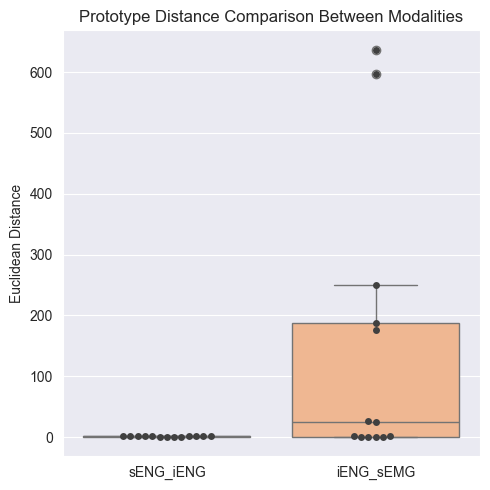

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# df는 이전에 Wilcoxon 검정에 사용한 dataframe 그대로 사용
# "sENG_iENG"와 "iENG_sEMG" 비교 시각화

# Boxplot용 데이터 변환
df_long = pd.melt(
    df,
    id_vars=["Feature", "Gesture"],
    value_vars=["sENG_iENG", "iENG_sEMG"],
    var_name="Modality_Pair",
    value_name="Distance"
)

plt.figure(figsize=(5, 5))
sns.boxplot(data=df_long, x="Modality_Pair", y="Distance", palette="pastel")
sns.swarmplot(data=df_long, x="Modality_Pair", y="Distance", color=".25", size=5)

plt.title("Prototype Distance Comparison Between Modalities")
plt.xlabel("")
plt.ylabel("Euclidean Distance")
plt.tight_layout()
plt.show()